# 01 - Extract Feature Vectors  (Stage 1)

**Purpose.** Read every Parcels Zarr store and, for each trajectory, record the
particle position at each day in `config.DAYS` (**50, 100, 150 days** after *its
own* release):

`X_i = [lat_50, lon_50, lat_100, lon_100, lat_150, lon_150]`

plus the release date / month / year and a survival `status`.

**Inputs.**  ~1,628 `Parcels_run_*.zarr` stores (10,000 trajectories each)
listed by `config.list_stores()`.

**Output.**  `data/features.parquet` (one row per trajectory).

**Notes about this dataset (verified from the Zarr metadata):**
- Output frequency is **6-hourly**, time is absolute `datetime64` (NaT after a
  particle is deleted), longitude is already in -180..180, so no conversion.
- The number of obs **varies per store** (925 / 740 / ... and some are
  truncated to ~185 obs ≈ 46 days at the end of the forcing data). Each day in
  `DAYS` is therefore found by *time*, not a fixed index; truncated stores fall
  out as `early_loss` / `partial` automatically. Adding day 150 means noticeably
  more particles are `partial` (deleted between day 100 and 150) than in the
  50/100-day project.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # project root: config.py, pipeline.py
import numpy as np
import pandas as pd
import config as C
import pipeline as P
print("project root:", C.PROJECT_ROOT)
print("sampling days:", C.DAYS, "| feature space:", C.FEATURE_SPACE)

project root: /work/bk1450/b383184/Amazon/Mercator/notebooks/Analysis/kmeans_analysis/kmean_analysis_50_150_stdZ
sampling days: [30, 50, 100, 150] | feature space: zscore


## 1.1  Configuration

In [2]:
stores = C.list_stores()
print(f"{len(stores)} stores  ->  ~{len(stores)*C.TRAJ_PER_STORE:,} trajectories")
print("sampling days:", C.DAYS, "| tolerance(d):", C.TIME_TOL_DAYS)
print("writing per-store parts to:", C.FEATURE_PARTS_DIR)
stores[:3]

1628 stores  ->  ~16,280,000 trajectories
sampling days: [30, 50, 100, 150] | tolerance(d): 1.0
writing per-store parts to: /work/bk1450/b383184/Amazon/Mercator/notebooks/Analysis/kmeans_analysis/kmean_analysis_50_150_stdZ/data/features_parts


[PosixPath('/work/bk1450/b383184/Amazon/Mercator/data/tracks_45678/Parcels_run_45678_1993-01-06 00:00:00.zarr'),
 PosixPath('/work/bk1450/b383184/Amazon/Mercator/data/tracks_45678/Parcels_run_45678_1993-01-11 00:00:00.zarr'),
 PosixPath('/work/bk1450/b383184/Amazon/Mercator/data/tracks_45678/Parcels_run_45678_1993-01-16 00:00:00.zarr')]

## 1.2  Sanity check on a single store

`pipeline.extract_store_features` does the vectorised work: it converts each
obs time to *days since that particle's release*, finds the nearest valid obs to
each day in `DAYS`, and assigns the status. Inspect one store first.

In [3]:
df0 = P.extract_store_features(stores[0], 0)
print(df0.status.value_counts())
df0.head()

status
complete      10000
partial           0
early_loss        0
Name: count, dtype: int64


,trajectory_id,store,lat_30,lon_30,lat_50,lon_50,lat_100,lon_100,lat_150,lon_150,release_time,release_month,release_year,status
0,0,Parcels_run_45678_1993-01-06 00:00:00,3.480911,-50.994202,4.631816,-52.040516,5.948242,-54.418770,7.535985,-58.604191,1993-01-06,1,1993,complete
1,1,Parcels_run_45678_1993-01-06 00:00:00,1.458176,-49.457882,1.458176,-49.457882,1.458176,-49.457882,1.458176,-49.457882,1993-01-06,1,1993,complete
2,2,Parcels_run_45678_1993-01-06 00:00:00,6.417256,-53.159443,11.972417,-59.967152,12.858086,-57.849583,13.715613,-53.279808,1993-01-06,1,1993,complete
3,3,Parcels_run_45678_1993-01-06 00:00:00,4.179047,-51.209969,4.952629,-52.463585,5.896968,-55.233902,7.800431,-58.908817,1993-01-06,1,1993,complete
4,4,Parcels_run_45678_1993-01-06 00:00:00,2.958115,-50.723389,4.642740,-52.032959,5.943859,-54.374329,7.041492,-58.328289,1993-01-06,1,1993,complete


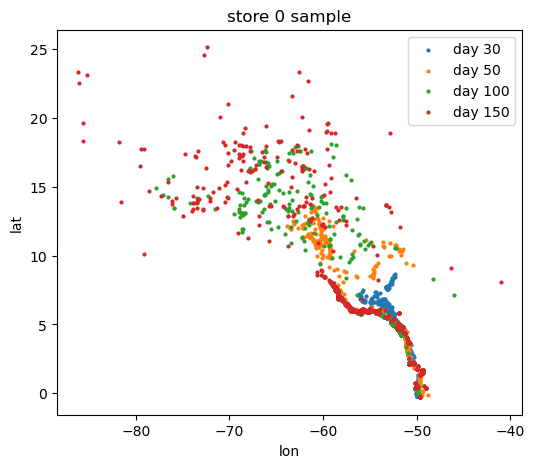

In [4]:
# Quick scatter of the first 1000 positions at each day as a sanity check.
import matplotlib.pyplot as plt
sub = df0[df0.status == "complete"].head(1000)
fig, ax = plt.subplots(figsize=(6, 5))
for d in C.DAYS:
    ax.scatter(sub[f"lon_{d}"], sub[f"lat_{d}"], s=4, label=f"day {d}")
ax.set_xlabel("lon"); ax.set_ylabel("lat"); ax.legend(); ax.set_title("store 0 sample")
plt.show()

## 1.3  Process all stores (parallel across stores)

Each store is independent, so we process them **in parallel with joblib** (one
process per store, `loky` backend, so the NumPy work sidesteps the GIL). We write
one small parquet per store into `data/features_parts/`. This keeps memory flat
(one store = 10k rows per worker) and makes the loop restartable: already-written
parts are skipped, so re-running only fills the gaps.

Set `N_JOBS` to the cores you actually have. In a SLURM job it defaults to
`$SLURM_CPUS_PER_TASK`. Do **not** also start a dask `Client` here — pick one
parallelism scheme, not both.

In [5]:
from joblib import Parallel, delayed

N_JOBS = int(os.environ.get("SLURM_CPUS_PER_TASK", 8))   # cores to use

def _extract_one(i, s):
    part = C.FEATURE_PARTS_DIR / f"part_{i:05d}.parquet"
    if part.exists():
        return None                      # restartable: skip finished stores
    P.extract_store_features(s, i).to_parquet(part, index=False)
    return i

print(f"extracting {len(stores)} stores with n_jobs={N_JOBS} ...")
Parallel(n_jobs=N_JOBS, backend="loky", verbose=10)(
    delayed(_extract_one)(i, s) for i, s in enumerate(stores)
)
print("done -> wrote", len(list(C.FEATURE_PARTS_DIR.glob('part_*.parquet'))), "parts")

extracting 1628 stores with n_jobs=8 ...


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    4.3s
[Parallel(n_jobs=8)]: Done   9 tasks      | elapsed:    5.5s
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:    5.7s
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    8.0s
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    9.3s
[Parallel(n_jobs=8)]: Done  45 tasks      | elapsed:   10.8s
[Parallel(n_jobs=8)]: Done  56 tasks      | elapsed:   12.2s
[Parallel(n_jobs=8)]: Done  69 tasks      | elapsed:   14.6s
[Parallel(n_jobs=8)]: Done  82 tasks      | elapsed:   16.1s
[Parallel(n_jobs=8)]: Done  97 tasks      | elapsed:   18.4s
[Parallel(n_jobs=8)]: Done 112 tasks      | elapsed:   20.7s
[Parallel(n_jobs=8)]: Done 129 tasks      | elapsed:   23.1s
[Parallel(n_jobs=8)]: Done 146 tasks      | elapsed:   25.5s
[Parallel(n_jobs=8)]: Done 165 tasks      | elapsed:   27.9s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:   30.4s
[Parallel(

done -> wrote 1628 parts


[Parallel(n_jobs=8)]: Done 1628 out of 1628 | elapsed:  3.9min finished


## 1.4  Combine parts into a single `features.parquet`

In [6]:
parts = sorted(C.FEATURE_PARTS_DIR.glob("part_*.parquet"))
features = pd.concat((pd.read_parquet(p) for p in parts), ignore_index=True)
features.to_parquet(C.FEATURES_FILE, index=False)
print("combined shape:", features.shape, "->", C.FEATURES_FILE)

combined shape: (16280000, 14) -> /work/bk1450/b383184/Amazon/Mercator/notebooks/Analysis/kmeans_analysis/kmean_analysis_50_150_stdZ/data/features.parquet


## 1.5  Summary

In [7]:
vc = features.status.value_counts()
print(f"Extracted features for {len(features):,} trajectories.")
for k in ["complete", "partial", "early_loss"]:
    print(f"  {k:10s}: {vc.get(k,0):,}")
print(f"release years: {features.release_year.min()}-{features.release_year.max()}")
print(f"Saved to {C.FEATURES_FILE}")

Extracted features for 16,280,000 trajectories.
  complete  : 15,679,487
  partial   : 480,513
  early_loss: 120,000
release years: 1993-2013
Saved to /work/bk1450/b383184/Amazon/Mercator/notebooks/Analysis/kmeans_analysis/kmean_analysis_50_150_stdZ/data/features.parquet
